In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import init_creds as creds
import sys
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage, ToolMessage

from pydantic import BaseModel, Field
from typing import Literal


In [3]:
sys.path.insert(1, '../../')

# # Configure Azure OpenAI And OpenAI Embeddings
# AZURE_OPENAI_KEY = os.getenv('OPENAI_API_KEY')
# AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
# AZURE_OPENAI_API_VERSION = os.getenv('OPENAI_API_VERSION')


AZURE_OPENAI_KEY = creds.get_api_key()
AZURE_OPENAI_ENDPOINT = creds.get_endpoint()
AZURE_OPENAI_API_VERSION = "2025-04-01-preview"

if not AZURE_OPENAI_KEY:
    raise ValueError("No AZURE_OPENAI_KEY set for Azure OpenAI API")
if not AZURE_OPENAI_ENDPOINT:
    raise ValueError("No AZURE_OPENAI_ENDPOINT set for Azure OpenAI API")

llm = AzureChatOpenAI(
    model="gpt-4o-mini",
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_KEY,
    api_version=AZURE_OPENAI_API_VERSION
)

In [4]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

In [5]:
# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

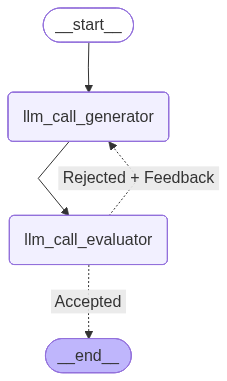

In [6]:
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [7]:
# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

Why was the cat sitting on the computer?  

Because it wanted to keep an eye on the mouse!


In [14]:
print("--- Graph Execution Log ---")
final_state = {}
for event in optimizer_workflow.stream({"topic": "Cats"}):
    for node_name, value in event.items():
        print(f"Node invoked: {node_name}")
        final_state.update(value)

print("\n--- Final Joke ---")
print(final_state["joke"])

--- Graph Execution Log ---
Node invoked: llm_call_generator
Node invoked: llm_call_evaluator

--- Final Joke ---
Why was the cat sitting on the computer?

Because it wanted to keep an eye on the mouse!
